# Regresión lineal del precio de la vivienda en EE. UU.

## Primer de regresión lineal

En estadística, la regresión lineal es un enfoque lineal para modelar la relación entre una variable dependiente escalar y y una o más variables explicativas (o variables independientes) denominadas X. El caso de una variable explicativa se denomina regresión lineal simple. Para más de una variable explicativa, el proceso se denomina regresión lineal múltiple.

Los modelos de regresión lineal a menudo se ajustan utilizando el enfoque de mínimos cuadrados, pero también pueden ajustarse de otras formas, como minimizando la "falta de ajuste" en alguna otra norma (como con la regresión de desviaciones mínimas absolutas), o minimizando una penalización. versión de la función de pérdida por mínimos cuadrados como en la regresión de crestas (penalización de $L_2$ -norm) y lazo (penalización de $L_1$ -norm). Por el contrario, el enfoque de mínimos cuadrados se puede utilizar para ajustar modelos que no son modelos lineales. Por lo tanto, aunque los términos "mínimos cuadrados" y "modelo lineal" están estrechamente relacionados, no son sinónimos.

### Importando paquetes y el conjunto de datos

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import numpy as np # Asegúrate de tener numpy también si usas np.sqrt u otras funciones



Código

In [45]:
#df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/USA_Housing.csv")
#df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv")

df.head()  # vemos los 5 primeros datos del dataframe

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive,14
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal,14
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal,30
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal,1
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal,24


Vista previa de los datos:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,146,Elective,2022-12-01,Aspirin,Inconclusive
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,47304.064845,404,Emergency,2023-06-15,Lipitor,Normal
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton LLC,Medicare,36874.896997,292,Emergency,2019-02-08,Lipitor,Normal
3,Antonio Frederick,49,Male,B-,Asthma,2020-05-02,Brian Chandler,Garcia Ltd,Medicare,23303.322092,480,Urgent,2020-05-03,Penicillin,Abnormal
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown and Murray",UnitedHealthcare,18086.344184,477,Urgent,2021-08-02,Paracetamol,Normal



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), o

,Age,Billing Amount,Room Number
count,10000.000000,10000.000000,10000.000000
mean,51.452200,25516.806778,300.082000
std,19.588974,14067.292709,115.806027
min,18.000000,1000.180837,101.000000
25%,35.000000,13506.523967,199.000000
50%,52.000000,25258.112566,299.000000
75%,68.000000,37733.913727,400.000000
max,85.000000,49995.902283,500.000000


Shape final tras limpieza: (10000, 16)
Train: (8000, 10), Test: (2000, 10)
Entrenando modelos...

Linear Regression:
   MAE  : $12,236.91
   RMSE : $14,130.23
   R²   : 0.0011

Ridge (L2):
   MAE  : $12,236.87
   RMSE : $14,130.11
   R²   : 0.0011

Lasso (L1):
   MAE  : $12,236.82
   RMSE : $14,129.44
   R²   : 0.0012

Random Forest:
   MAE  : $12,400.63
   RMSE : $14,398.32
   R²   : -0.0372

Gradient Boosting:
   MAE  : $12,271.71
   RMSE : $14,175.45
   R²   : -0.0053

Resumen de Modelos (ordenado por RMSE):
                        MAE      RMSE      R²
Lasso (L1)        12,236.82 14,129.44  0.0012
Ridge (L2)        12,236.87 14,130.11  0.0011
Linear Regression 12,236.91 14,130.23  0.0011
Gradient Boosting 12,271.71 14,175.45 -0.0053
Random Forest     12,400.63 14,398.32 -0.0372

Mejor modelo: Lasso (L1)


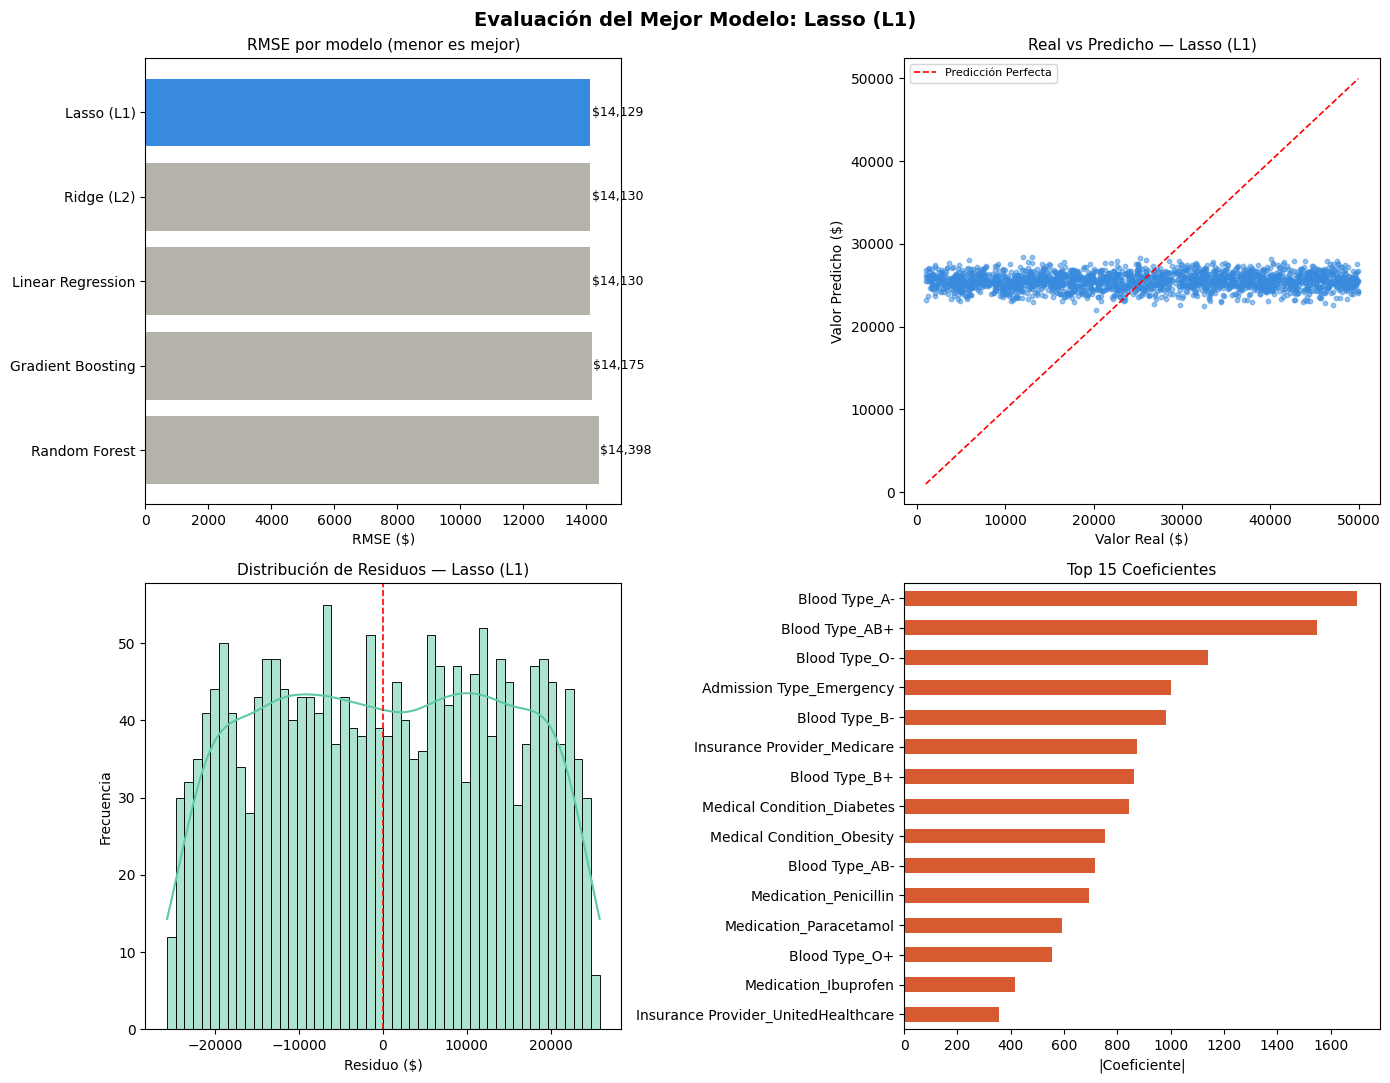

--- Predicción para nuevo paciente ---
Modelo usado: Lasso (L1)
Billing Amount predicho: $23,748.53


In [46]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# 2. CARGA Y EXPLORACIÓN DE DATOS
# ==============================================================================
# Cargamos el dataset
df = pd.read_csv("https://github.com/ulewis/Ejemplos/raw/main/Datos/healthcare_dataset.csv")

# Ver primeras filas
print("Vista previa de los datos:")
display(df.head())

# Información básica
print("\nInformación del DataFrame:")
df.info()

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
display(df.describe())

# ==============================================================================
# 3. PREPROCESAMIENTO DE DATOS
# ==============================================================================
# Eliminar nulos y duplicados
df = df.dropna()
df = df.drop_duplicates()

# Convertir fechas y calcular duración de estancia
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"])
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"])
df["Length of Stay"] = (df["Discharge Date"] - df["Date of Admission"]).dt.days

# Limpiar espacios en blanco en variables categóricas
cat_cols = ["Gender", "Blood Type", "Medical Condition",
            "Admission Type", "Medication", "Test Results",
            "Insurance Provider"]

for col in cat_cols:
    df[col] = df[col].str.strip()

# Eliminar outliers en Billing Amount (opcional, pero recomendado)
Q1 = df["Billing Amount"].quantile(0.25)
Q3 = df["Billing Amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["Billing Amount"] >= lower) & (df["Billing Amount"] <= upper)]

print(f"Shape final tras limpieza: {df.shape}")

# ==============================================================================
# 4. SELECCIÓN DE FEATURES Y PREPARACIÓN
# ==============================================================================
# Definir características numéricas y categóricas
features_num = ["Age", "Room Number", "Length of Stay"]
features_cat = ["Gender", "Blood Type", "Medical Condition",
                "Admission Type", "Medication", "Test Results",
                "Insurance Provider"]

target = "Billing Amount"

# Seleccionar columnas relevantes
df_model = df[features_num + features_cat + [target]].copy()

# Separar X e y
X = df_model.drop(columns=[target])
y = df_model[target]

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# ==============================================================================
# 5. CREACIÓN DE PIPELINES (PREPROCESAMIENTO + MODELO)
# ==============================================================================

# Preprocesador: Escala numéricas y Codifica categóricas
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ])

# Definir modelos a probar
models = {
    "Linear Regression": Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', LinearRegression())]),
    "Ridge (L2)": Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', Ridge(alpha=1.0))]),
    "Lasso (L1)": Pipeline(steps=[('preprocessor', preprocessor),
                                   ('regressor', Lasso(alpha=1.0, max_iter=5000))]),
    "Random Forest": Pipeline(steps=[('preprocessor', preprocessor),
                                     ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    "Gradient Boosting": Pipeline(steps=[('preprocessor', preprocessor),
                                         ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, random_state=42))])
}

# ==============================================================================
# 6. ENTRENAMIENTO Y EVALUACIÓN
# ==============================================================================
results = {}

print("Entrenando modelos...\n")
for name, model_pipeline in models.items():
    # Entrenar
    model_pipeline.fit(X_train, y_train)

    # Predecir
    y_pred = model_pipeline.predict(X_test)

    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R²": r2, "model": model_pipeline, "preds": y_pred}

    print(f"{name}:")
    print(f"   MAE  : ${mae:,.2f}")
    print(f"   RMSE : ${rmse:,.2f}")
    print(f"   R²   : {r2:.4f}\n")

# Crear DataFrame resumen
summary = pd.DataFrame({
    k: {"MAE": v["MAE"], "RMSE": v["RMSE"], "R²": v["R²"]}
    for k, v in results.items()
}).T.sort_values("RMSE")

print("Resumen de Modelos (ordenado por RMSE):")
print(summary.to_string(float_format=lambda x: f"{x:,.2f}" if x > 1 else f"{x:.4f}"))

# Identificar el mejor modelo
best_name = summary.index[0]
best_model_pipeline = results[best_name]["model"]
y_pred_best = results[best_name]["preds"]

print(f"\nMejor modelo: {best_name}")

# ==============================================================================
# 7. VISUALIZACIÓN DE RESULTADOS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f"Evaluación del Mejor Modelo: {best_name}", fontsize=14, fontweight="bold")

# 1. Comparación de RMSE entre modelos
ax = axes[0, 0]
model_names = summary.index.tolist()
rmse_vals = summary["RMSE"].values
colors = ["#378ADD" if n == best_name else "#B4B2A9" for n in model_names]
bars = ax.barh(model_names, rmse_vals, color=colors)
ax.set_xlabel("RMSE ($)")
ax.set_title("RMSE por modelo (menor es mejor)", fontsize=11)
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=9)
ax.invert_yaxis()

# 2. Real vs Predicho
ax = axes[0, 1]
ax.scatter(y_test, y_pred_best, alpha=0.5, s=10, color="#378ADD")
mn = min(y_test.min(), y_pred_best.min())
mx = max(y_test.max(), y_pred_best.max())
ax.plot([mn, mx], [mn, mx], "r--", linewidth=1.2, label="Predicción Perfecta")
ax.set_xlabel("Valor Real ($)")
ax.set_ylabel("Valor Predicho ($)")
ax.set_title(f"Real vs Predicho — {best_name}", fontsize=11)
ax.legend(fontsize=8)

# 3. Distribución de Residuos
ax = axes[1, 0]
residuals = y_test.values - y_pred_best
sns.histplot(residuals, bins=50, kde=True, ax=ax, color="#5DCAA5")
ax.axvline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residuo ($)")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Distribución de Residuos — {best_name}", fontsize=11)

# 4. Importancia de Características (Solo si es Random Forest o GBM)
ax = axes[1, 1]
if "Random Forest" in best_name or "Gradient" in best_name:
    # Obtener el paso del regresor dentro del pipeline
    regressor_step = best_model_pipeline.named_steps['regressor']
    # Obtener nombres de features después del preprocesamiento
    feature_names = (features_num +
                     list(best_model_pipeline.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .get_feature_names_out(features_cat)))

    importances = pd.Series(regressor_step.feature_importances_, index=feature_names)
    top15 = importances.nlargest(15).sort_values()
    top15.plot(kind="barh", ax=ax, color="#D85A30")
    ax.set_xlabel("Importancia")
    ax.set_title("Top 15 Features", fontsize=11)
else:
    # Si es Lineal, mostramos coeficientes absolutos
    regressor_step = best_model_pipeline.named_steps['regressor']
    feature_names = (features_num +
                     list(best_model_pipeline.named_steps['preprocessor']
                          .named_transformers_['cat']
                          .get_feature_names_out(features_cat)))
    coefs = pd.Series(np.abs(regressor_step.coef_), index=feature_names)
    top15 = coefs.nlargest(15).sort_values()
    top15.plot(kind="barh", ax=ax, color="#D85A30")
    ax.set_xlabel("|Coeficiente|")
    ax.set_title("Top 15 Coeficientes", fontsize=11)

plt.tight_layout()
plt.show()

# ==============================================================================
# 8. PREDICCIÓN CON NUEVOS DATOS
# ==============================================================================

# Ejemplo de nuevo paciente
nuevo_paciente = pd.DataFrame([{
    "Age": 55,
    "Room Number": 320,
    "Length of Stay": 7,
    "Gender": "Female",
    "Blood Type": "A+",
    "Medical Condition": "Cancer",
    "Admission Type": "Emergency",
    "Medication": "Lipitor",
    "Test Results": "Abnormal",
    "Insurance Provider": "Medicare",
}])

# El pipeline se encarga del preprocesamiento automáticamente
pred_val = best_model_pipeline.predict(nuevo_paciente)[0]

print(f"--- Predicción para nuevo paciente ---")
print(f"Modelo usado: {best_name}")
print(f"Billing Amount predicho: ${pred_val:,.2f}")

Discusión de resultados

Según las predicciones, significa el R**2 como ajuste de predicciones a los datos reales que el modelo no está acertando, sino que practicamente,está adivinando.
No ha encontrado ninguna relación entre la edad, el género, y el tipo de sangre en relación al costo de la factura.

En base al Mean Square Error , el modelo se equivoca por 12 mil dolares. El root Mean Square los considera aún mayor, severamente.

Siendo un fallo del monto promedio de 25 500 dolares, este error es mayor al 50% del valor real.


Esto ocurre porque ninguna de estas variables determina el precio directamente, o que la relación sea extremadamente débil, o ruidosa.
Por una parte, el número de cuarto es aleatorio, por otra, el género, y tipo de sangre no suele asociarse a la facturación específica asociada.
La condición médica sí debería estar incluída, pero dado que hay muchas condiciones distintas, y pocas muestras por cada una, el modelo no corrige la importancia de una mejor ingeniería de características.


Conclusiones:

El modelo tuvo un desarrollo ineficaz, dado la ingeniería de características ineficiente, resultando el 50% a más de pérdidas en los resultados obtenidos.

Por lo tanto, esta práctica podría mejorar, creando variables más relevantes, como Días de estancia, y severidad de condiciones, entre otros, como eliminar el ruido, verificar la fuga de datos inversa, etc.


